## Silver EDA (Deliverables 1.2.2 and 1.2.3)

This notebook performs data profiling, exploratory analysis, and feature behavior review on the Silver pump dataset. It focuses on comparing normal and abnormal operating behavior to understand how the sensors change around failure periods.

The key goals of this notebook are:

- To document data profiling and exploratory analysis for the Silver layer.
- To analyze feature behavior across normal and abnormal operating patterns.
- To generate supporting Silver-layer artifacts (tables, profiles, and charts) that help justify the later model design in the Gold layer.

Outputs from this notebook support the project write-up in Section C by:

- Providing evidence for the anomaly-screening approach described in C.2 and C.2.A.
- Supplying behavior profiles and feature effect-size information that are used to design the Stage 3 rule/profile/historical confirmation layer described in C.2.
- Providing visualizations that can be used in C.6 to communicate how sensor behavior differs between normal and abnormal operation.

In [ ]:
from __future__ import annotations

from dataclasses import dataclass, field
from datetime import datetime, timezone
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union

#import os
#import glob

from pathlib import Path
import yaml
import re

import logging
import wandb

import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split, KFold

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering


from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import pyarrow.parquet as pq
import pyarrow as pa


import hashlib


# Custom Utilities Module
from utils.paths import get_paths
from utils.file_io import load_data, save_data, save_json, load_json
from utils.eda_logging import profile_dataframe
from utils.logging_setup import configure_logging
from utils.wandb_utils import finalize_wandb_stage

# Ledger 
from utils.ledger import Ledger

# Show more columns
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)






In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
def log_silver_paths(paths, logger: logging.Logger) -> None:
    logger.info("Project Root Path Loaded: %s", paths.root)
    logger.info("Project Logging Path Loaded: %s", paths.logs)
    logger.info("Project Artifacts Path Loaded: %s", paths.artifacts)
    logger.info("Project Notebooks Path Loaded %s", paths.notebooks)
    logger.info("Project Data Path Loaded: %s", paths.data)
    logger.info("Data Bronze Path Loaded: %s", paths.data_bronze)
    logger.info("Data Bronze Training Path Loaded: %s", paths.data_bronze_train)
    logger.info("Data Bronze Testing Path Loaded: %s", paths.data_bronze_test)
    logger.info("Data Silver Path Loaded: %s", paths.data_silver)
    logger.info("Data Silver Training Path Loaded: %s", paths.data_silver_train)
    logger.info("Data Silver Testing Path Loaded: %s", paths.data_silver_test)

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
def z_score(series: pd.Series) -> pd.Series:
    series = series.astype(float)
    mean_value = float(series.mean())
    std_value = float(series.std(ddof=1)) if series.shape[0] > 1 else 0.0
    if std_value == 0.0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - mean_value) / std_value


In [ ]:
def z_score_series(series: pd.Series) -> pd.Series:
    """
    Z-score normalize a numeric pandas Series.
    Returns a Series with the same index.
    If std is 0 or NaN (constant series), returns series - mean.
    """
    # Ensure float dtype
    s = series.astype(float)

    # Use nan-safe stats in case any NaNs sneak in
    mean = np.nanmean(s.values)
    std = np.nanstd(s.values)

    if std == 0 or np.isnan(std):
        # All values are (effectively) the same -> center only
        return s - mean

    return (s - mean) / std

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
# Configurables

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

# Stage Details
STAGE = "silver_eda"
LAYER_NAME = "silver_eda"
SILVER_VERSION = "silver_eda__001"
CLEANING_RECIPE_ID = "silver_eda__v001"


DATASET_NAME_CONFIG = "pump"
DATASET_NAME = str(DATASET_NAME_CONFIG).strip().lower()

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

# File Names
SILVER_TRAIN_DATA_FILE_NAME = f"{DATASET_NAME}__silver__train.parquet"
FEATURE_REGISTRY_FILE_NAME = f"{DATASET_NAME}__silver__feature_registry.json"

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 


# Weights and Biases

WANDB_PROJECT = "capstone"
WANDB_ENTITY = "dcoo230-western-governors-university"
WANDB_RUN_NAME = f"{SILVER_VERSION}"


#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

# QA/EDA thresholds

# Thresholds
MIN_TIME_PARSE_SUCCESS_PERCENT = 95.0
MIN_STEP_PARSE_SUCCESS_PERCENT = 95.0

QUARANTINE_MISSING_PCT = 30.0
CORRELATION_THRESHOLD = 0.85

# EDA Controls
TOP_N_SENSORS_FOR_PLOTS = 8
PAIRPLOT_SENSOR_CAP = 8
PAIRPLOT_SAMPLE_N = 2000
TOP_PLOT_COLS = 8
TOP_CORR_COLS = 15

ROLLING_MINUTES = 60
LOOKBACK_HOURS = 48
BASELINE_DAYS = 7
BASELINE_GAP_HOURS = 12
SUSTAIN_MINUTES = 180
TOP_SENSOR_PRE_HOURS = 6

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 


PRE_WINDOW_STEPS = 200
POST_WINDOW_STEPS = 200
MAX_ONSETS_TO_USE = 30
PCA_SAMPLE_ROW_COUNT = 8000
USE_ROBUST_SCALER = True
IMPUTE_SAMPLE_ROW_COUNT = 20000


#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

# Canonical Outputs

CANONICAL_OUTPUT_COLUMNS = [
    "event_time",
    "event_step",
    "time_index",
]

CANONICAL_NON_META_ORDER = [
    "event_time",
    "event_step",
    "time_index",
    "event_date",
]

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

# Meta Columns


SILVER_META_COLS_ADDED = [
    "meta__layer",
    "meta__processed_at_utc",
    "meta__silver_version",
    "meta__cleaning_recipe_id",
    "meta__dataset_name", 
    "meta__dataset_source",
    "meta__source_dataset",
    "meta__has_label_candidates",
    "meta__has_status_candidates",
    "meta__event_id",
    "meta__event_time_source",
    "meta__event_step_source",
    "meta__feature_set",
]



META_REQUIRED_COLUMNS = [
    "meta__dataset",
    "meta__split",
    "meta__run_id",
    "meta__asset_id",
    "meta__source_file",
    "meta__source_row_id",
]

META_SILVER_ADDED_COLUMNS = [
    "meta__layer",
    "meta__processed_at_utc",
    "meta__dataset_name",
    "meta__dataset_source",
    "meta__feature_set_id",
    "meta__feature_count",
    "meta__label_source_column",
    "meta__label_source_kind",
]



#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

CANONICAL_EXCLUDE_COLUMNS = [
    "event_time",
    "event_step",
    "time_index",
    "event_date",
    "meta__event_id",
    "meta__event_time_source",
    "meta__event_step_source",
    "meta__event_time_parse_success_percent",
    "meta__event_step_parse_success_percent",
]

LABEL_EXCLUDE_COLUMNS = [
    "anomaly_flag",
    "is_anomaly",
    "is_normal",
    "status_normal_value",
    "meta__label_source",
    "meta__label_type",
]

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 


CANONICAL_NON_META_ORDER = ["event_time", "event_step", "time_index", "event_date"]

LABEL_COLUMNS_ORDER = [
    "anomaly_flag",
    "is_anomaly",
    "is_normal",
    "status_normal_value",
    "meta__label_source",
    "meta__label_type",
]

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####





In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
# Paths Setup

# Get Path's Object
paths = get_paths()

# Paths
SILVER_TRAIN_DATA_PATH = paths.data_silver_train

SILVER_ARTIFACTS_PATH = paths.artifacts / "silver" / DATASET_NAME
#SILVER_ARTIFACTS_PATH = paths.artifacts / "silver" 
SILVER_EDA_ARTIFACTS_PATH = paths.artifacts / "silver_eda" / DATASET_NAME

FEATURE_REGISTRY_PATH = SILVER_ARTIFACTS_PATH / FEATURE_REGISTRY_FILE_NAME

LOGS_PATH = paths.logs

# Path Failsafes
SILVER_TRAIN_DATA_PATH.mkdir(parents=True, exist_ok=True)
SILVER_ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)

SILVER_EDA_ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)

LOGS_PATH.mkdir(parents=True, exist_ok=True)


In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
# Logging Setup

# Create silver log path 
silver_log_path = paths.logs / "silver_eda.log"

# Initial Logger
configure_logging(
    "capstone",
    silver_log_path,
    level=logging.DEBUG,
    overwrite_handlers=True,
)

# Initiate Logger and log file
logger = logging.getLogger("capstone.silver_eda")

# Log load and initiation
logger.info("Silver EDA stage starting")

# Log paths loads
log_silver_paths(paths, logger)


2026-03-01 04:53:25,142 | INFO | capstone.silver_eda | Silver EDA stage starting
2026-03-01 04:53:25,145 | INFO | capstone.silver_eda | Project Root Path Loaded: /workspace
2026-03-01 04:53:25,148 | INFO | capstone.silver_eda | Project Logging Path Loaded: /workspace/logs
2026-03-01 04:53:25,151 | INFO | capstone.silver_eda | Project Artifacts Path Loaded: /workspace/artifacts
2026-03-01 04:53:25,153 | INFO | capstone.silver_eda | Project Notebooks Path Loaded /workspace/notebooks
2026-03-01 04:53:25,155 | INFO | capstone.silver_eda | Project Data Path Loaded: /workspace/data


2026-03-01 04:53:25,157 | INFO | capstone.silver_eda | Data Bronze Path Loaded: /workspace/data/bronze
2026-03-01 04:53:25,161 | INFO | capstone.silver_eda | Data Bronze Training Path Loaded: /workspace/data/bronze/train
2026-03-01 04:53:25,164 | INFO | capstone.silver_eda | Data Bronze Testing Path Loaded: /workspace/data/bronze/test
2026-03-01 04:53:25,165 | INFO | capstone.silver_eda | Data Silver Path Loaded: /workspace/data/silver
2026-03-01 04:53:25,167 | INFO | capstone.silver_eda | Data Silver Training Path Loaded: /workspace/data/silver/train
2026-03-01 04:53:25,172 | INFO | capstone.silver_eda | Data Silver Testing Path Loaded: /workspace/data/silver/test


In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
# W&B

wandb_run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name=WANDB_RUN_NAME,
    job_type="silver_eda",
    config={
        "silver_version": SILVER_VERSION,
        "cleaning_recipe_id": CLEANING_RECIPE_ID,
        "quarantine_missing_pct": QUARANTINE_MISSING_PCT,
        "min_time_parse_success_percent": MIN_TIME_PARSE_SUCCESS_PERCENT,
        "rolling_window": ROLLING_MINUTES,
        "silver_path": str(SILVER_TRAIN_DATA_PATH / SILVER_TRAIN_DATA_FILE_NAME),
        "silver_out_dir": str(SILVER_TRAIN_DATA_PATH),
    },
)
logger.info("W&B initialized: %s", wandb.run.name)


feature_registry_keys,▁
silver_cols,▁
silver_rows,▁
feature_registry_keys,13
silver_cols,85
silver_rows,220320


2026-03-01 04:53:33,003 | INFO | capstone.silver_eda | W&B initialized: silver_eda__001


In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
# Ledger Setup

ledger = Ledger(stage=STAGE, recipe_id=CLEANING_RECIPE_ID)

ledger.add(
    kind="step",
    step="init",
    message="Initialized ledger",
    logger=logger
)


2026-03-01 04:53:33,026 | INFO | capstone.silver_eda | LEDGER | {'ts_utc': '2026-03-01T04:53:33.026275+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'init', 'message': 'Initialized ledger', 'why': None, 'consequence': None, 'data': {}}


{'ts_utc': '2026-03-01T04:53:33.026275+00:00',
 'stage': 'silver_eda',
 'recipe': 'silver_eda__v001',
 'kind': 'step',
 'step': 'init',
 'message': 'Initialized ledger',
 'why': None,
 'consequence': None,
 'data': {}}

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
# Load Data

preferred_silver = SILVER_TRAIN_DATA_PATH / SILVER_TRAIN_DATA_FILE_NAME

if preferred_silver.exists():
    silver_data_path = preferred_silver
else:
    parquet_files = sorted(SILVER_TRAIN_DATA_PATH.glob("*.parquet"))
    if len(parquet_files) == 0:
        raise FileNotFoundError(f"No parquet files found in {SILVER_TRAIN_DATA_PATH}")
    if len(parquet_files) > 1: 
        logger.warning("Multiple Parquet Files found; Using First %s", parquet_files[0])
    silver_data_path = parquet_files[0]

if not silver_data_path.exists():
    raise FileNotFoundError(f"Silver parquet not found: {silver_data_path}")
    
dataframe = load_data(silver_data_path.parent, silver_data_path.name)



#### #### #### #### #### #### #### #### 

logger.info("Loaded Silver: %s | shape=%s", silver_data_path, dataframe.shape)
wandb_run.log({"silver_rows": int(dataframe.shape[0]), "silver_cols": int(dataframe.shape[1])})

ledger.add(
    kind="step",
    step="load_silver",
    message="Loaded Silver Parquet",
    why="Silver must be derived from reprodicible Silver Artifact",
    consequence="All silver outputs trace back to this file",
    data={"silver_path": str(silver_data_path), "shape": list(dataframe.shape), "cols": len(dataframe.columns)},
    logger=logger
)


#### #### #### #### #### #### #### #### 

display(dataframe.head(3))

2026-03-01 04:53:33,086 | INFO | capstone.file_io | Loading Parquet: /workspace/data/silver/train/pump__silver__train.parquet


2026-03-01 04:53:33,995 | INFO | capstone.silver_eda | Loaded Silver: /workspace/data/silver/train/pump__silver__train.parquet | shape=(220320, 85)
2026-03-01 04:53:33,997 | INFO | capstone.silver_eda | LEDGER | {'ts_utc': '2026-03-01T04:53:33.997286+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'load_silver', 'message': 'Loaded Silver Parquet', 'why': 'Silver must be derived from reprodicible Silver Artifact', 'consequence': 'All silver outputs trace back to this file', 'data': {'silver_path': '/workspace/data/silver/train/pump__silver__train.parquet', 'shape': [220320, 85], 'cols': 85}}


,meta__asset_id,meta__cleaning_recipe_id,meta__dataset,meta__dataset_name,meta__dataset_source,meta__event_id,meta__event_time_parse_success_percent,meta__event_time_source,meta__feature_count,meta__feature_set_id,meta__has_label_candidates,meta__has_status_candidates,meta__ingested_at_utc,meta__label_source,meta__label_source_column,meta__label_source_kind,meta__label_type,meta__layer,meta__processed_at_utc,meta__record_id,meta__run_id,meta__silver_version,meta__source_file,meta__source_row_id,meta__split,event_time,event_step,time_index,event_date,anomaly_flag,is_anomaly,is_normal,status_normal_value,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_51,timestamp,machine_status
0,asset__001,silver__clean__dataset__agnostic__v001,pump,pump,meta__dataset,pump:asset__001:run__001:0,100.0,timestamp,50,feature_set__bea5fdd737ae53fcd80ca84cafcd0c40,0,1,2026-03-01 03:54:51.311816+00:00,<NA>,machine_status,status,<NA>,silver,2026-03-01 04:18:23.781532+00:00,14598431322315673869,run__001,silver__001,sensor.csv,0,unsplit,2018-04-01 00:00:00+00:00,0,0,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,2.465394,47.09201,53.2118,46.31076,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,201.3889,2018-04-01 00:00:00,NORMAL
1,asset__001,silver__clean__dataset__agnostic__v001,pump,pump,meta__dataset,pump:asset__001:run__001:1,100.0,timestamp,50,feature_set__bea5fdd737ae53fcd80ca84cafcd0c40,0,1,2026-03-01 03:54:51.311816+00:00,<NA>,machine_status,status,<NA>,silver,2026-03-01 04:18:23.781532+00:00,15954729095895098000,run__001,silver__001,sensor.csv,1,unsplit,2018-04-01 00:01:00+00:00,1,1,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,2.465394,47.09201,53.2118,46.31076,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,201.3889,2018-04-01 00:01:00,NORMAL
2,asset__001,silver__clean__dataset__agnostic__v001,pump,pump,meta__dataset,pump:asset__001:run__001:2,100.0,timestamp,50,feature_set__bea5fdd737ae53fcd80ca84cafcd0c40,0,1,2026-03-01 03:54:51.311816+00:00,<NA>,machine_status,status,<NA>,silver,2026-03-01 04:18:23.781532+00:00,10041703297090838359,run__001,silver__001,sensor.csv,2,unsplit,2018-04-01 00:02:00+00:00,2,2,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,2.444734,47.35243,53.2118,46.39757,638.8889,73.54598,13.32465,16.03733,15.61777,15.01013,37.86777,48.17723,32.08894,1.708474,420.8480,462.7798,459.6364,2.500062,666.2234,399.9418,880.4237,501.3617,982.7342,631.1326,740.8031,849.8997,454.2390,778.5734,715.6266,661.5740,721.8750,694.7721,441.2635,169.9820,343.1955,200.9694,93.90508,41.40625,31.25000,69.53125,30.46875,31.770830,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,203.7037,2018-04-01 00:02:00,NORMAL


In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
print("Silver training shape:", dataframe.shape)
dataframe.info()
display(dataframe.describe().T.head(10))

Silver training shape: (220320, 85)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 85 columns):
 #   Column                                  Non-Null Count   Dtype              
---  ------                                  --------------   -----              
 0   meta__asset_id                          220320 non-null  object             
 1   meta__cleaning_recipe_id                220320 non-null  object             
 2   meta__dataset                           220320 non-null  category           
 3   meta__dataset_name                      220320 non-null  object             
 4   meta__dataset_source                    220320 non-null  object             
 5   meta__event_id                          220320 non-null  object             
 6   meta__event_time_parse_success_percent  220320 non-null  float64            
 7   meta__event_time_source                 220320 non-null  object             
 8   meta__feature_count         

,count,mean,std,min,25%,50%,75%,max
meta__event_time_parse_success_percent,220320.0,1.000000e+02,0.000000e+00,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02
meta__feature_count,220320.0,5.000000e+01,0.000000e+00,5.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01
meta__has_label_candidates,220320.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
meta__has_status_candidates,220320.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
meta__record_id,220320.0,9.224243e+18,5.322367e+18,1.873763e+14,4.610703e+18,9.220552e+18,1.381850e+19,1.844674e+19
meta__source_row_id,220320.0,1.101595e+05,6.360105e+04,0.000000e+00,5.507975e+04,1.101595e+05,1.652392e+05,2.203190e+05
event_step,220320.0,1.101595e+05,6.360105e+04,0.000000e+00,5.507975e+04,1.101595e+05,1.652392e+05,2.203190e+05
time_index,220320.0,1.101595e+05,6.360105e+04,0.000000e+00,5.507975e+04,1.101595e+05,1.652392e+05,2.203190e+05
anomaly_flag,220320.0,6.574074e-02,2.478289e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
is_anomaly,220320.0,6.574074e-02,2.478289e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
feature_registry = load_json(FEATURE_REGISTRY_PATH.parent, FEATURE_REGISTRY_PATH.name)

#### #### #### #### #### #### #### #### 

logger.info("Loaded Silver Feature Registry: %s", FEATURE_REGISTRY_PATH )
wandb_run.log({"feature_registry_keys": int(len(feature_registry))})

ledger.add(
    kind="step",
    step="load_silver_feature_registry",
    message="Loaded Silver Feature Registry Json File",
    why="Silver Features Registry must be derived from reprodicible Silver Artifact",
    consequence="All silver outputs trace back to this file",
    data={"feature_registry_path": str(FEATURE_REGISTRY_PATH ), "keys": int(len(feature_registry))},
    logger=logger
)


#### #### #### #### #### #### #### #### 

2026-03-01 04:53:35,000 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/silver/pump/silver__pump__feature_registry.json
2026-03-01 04:53:35,012 | INFO | capstone.silver_eda | Loaded Silver Feature Registry: /workspace/artifacts/silver/pump/silver__pump__feature_registry.json
2026-03-01 04:53:35,015 | INFO | capstone.silver_eda | LEDGER | {'ts_utc': '2026-03-01T04:53:35.015711+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'load_silver_feature_registry', 'message': 'Loaded Silver Feature Registry Json File', 'why': 'Silver Features Registry must be derived from reprodicible Silver Artifact', 'consequence': 'All silver outputs trace back to this file', 'data': {'feature_registry_path': '/workspace/artifacts/silver/pump/silver__pump__feature_registry.json', 'keys': 13}}


{'ts_utc': '2026-03-01T04:53:35.015711+00:00',
 'stage': 'silver_eda',
 'recipe': 'silver_eda__v001',
 'kind': 'step',
 'step': 'load_silver_feature_registry',
 'message': 'Loaded Silver Feature Registry Json File',
 'why': 'Silver Features Registry must be derived from reprodicible Silver Artifact',
 'consequence': 'All silver outputs trace back to this file',
 'data': {'feature_registry_path': '/workspace/artifacts/silver/pump/silver__pump__feature_registry.json',
  'keys': 13}}

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
FEATURE_COLUMNS = feature_registry.get("feature_columns", [])
FEATURE_SET_ID = feature_registry.get("feature_set_id", "unknown_feature_set")

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
required_columns = [
    "anomaly_flag",
    "event_step",
    "time_index",
    "meta__asset_id",
    "meta__run_id",
]

present = {}
for column_name in required_columns:
    present[column_name] = bool(column_name in dataframe.columns)

overview = {
    "rows": int(len(dataframe)),
    "cols": int(len(dataframe.columns)),
    "required_present": present,
}

logger.info("Overview: %s", overview)

save_json(
    overview,
    file_path=SILVER_EDA_ARTIFACTS_PATH,
    file_name="silver_eda__overview.json",
)

wandb.save(str(SILVER_EDA_ARTIFACTS_PATH / "silver_eda__overview.json"))

2026-03-01 04:53:35,117 | INFO | capstone.silver_eda | Overview: {'rows': 220320, 'cols': 85, 'required_present': {'anomaly_flag': True, 'event_step': True, 'time_index': True, 'meta__asset_id': True, 'meta__run_id': True}}
2026-03-01 04:53:35,142 | INFO | capstone.file_io | Saved JSON: /workspace/artifacts/silver_eda/pump/silver_eda__overview.json


['/workspace/wandb/wandb/run-20260301_045325-484lyt2e/files/pump/silver_eda__overview.json']

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
total_rows = int(len(dataframe))

null_rows = []
for column_name in dataframe.columns:
    null_count = int(dataframe[column_name].isna().sum())
    null_percent = float((null_count / total_rows) * 100.0) if total_rows > 0 else 0.0
    null_rows.append({
        "column": column_name,
        "null_count": null_count,
        "null_percent": null_percent,
    })

null_table = pd.DataFrame(null_rows).sort_values("null_percent", ascending=False)

null_all_path = SILVER_EDA_ARTIFACTS_PATH / "nulls__all_columns.csv"
null_table.to_csv(null_all_path, index=False)
wandb.save(str(null_all_path))

feature_null_table = null_table[null_table["column"].isin(FEATURE_COLUMNS)].copy()
feature_null_path = SILVER_EDA_ARTIFACTS_PATH / "nulls__feature_columns.csv"
feature_null_table.to_csv(feature_null_path, index=False)
wandb.save(str(feature_null_path))

null_table.head(15), feature_null_table.head(15)

(                column  null_count  null_percent
 16    meta__label_type      220320    100.000000
 13  meta__label_source      220320    100.000000
 82           sensor_51       15383      6.982117
 33           sensor_00       10208      4.633261
 40           sensor_07        5451      2.474129
 41           sensor_08        5107      2.317992
 39           sensor_06        4798      2.177741
 42           sensor_09        4595      2.085603
 34           sensor_01         369      0.167484
 62           sensor_30         261      0.118464
 61           sensor_29          72      0.032680
 64           sensor_32          68      0.030864
 50           sensor_18          46      0.020879
 49           sensor_17          46      0.020879
 54           sensor_22          41      0.018609,
        column  null_count  null_percent
 82  sensor_51       15383      6.982117
 33  sensor_00       10208      4.633261
 40  sensor_07        5451      2.474129
 41  sensor_08        5107      2.3

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
duplicate_row_count = int(dataframe.duplicated().sum())

duplicate_event_id_count = None
if "meta__event_id" in dataframe.columns:
    duplicate_event_id_count = int(dataframe["meta__event_id"].duplicated().sum())

dup_info = {
    "duplicate_row_count": duplicate_row_count,
    "duplicate_meta__event_id_count": duplicate_event_id_count,
}

save_json(dup_info, file_path=SILVER_EDA_ARTIFACTS_PATH, file_name="duplicates__summary.json")
wandb.save(str(SILVER_EDA_ARTIFACTS_PATH / "duplicates__summary.json"))

dup_info

2026-03-01 04:53:36,310 | INFO | capstone.file_io | Saved JSON: /workspace/artifacts/silver_eda/pump/duplicates__summary.json


{'duplicate_row_count': 0, 'duplicate_meta__event_id_count': 0}

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
numeric_columns = dataframe.select_dtypes(include=["number"]).columns.tolist()
numeric_describe = dataframe[numeric_columns].describe().T if len(numeric_columns) > 0 else pd.DataFrame()

numeric_stats_path = SILVER_EDA_ARTIFACTS_PATH / "column_stats__numeric_describe.csv"
numeric_describe.to_csv(numeric_stats_path)
wandb.save(str(numeric_stats_path))

categorical_like_columns = dataframe.select_dtypes(include=["object", "category", "string"]).columns.tolist()

cardinality_rows = []
for column_name in categorical_like_columns:
    unique_count = int(dataframe[column_name].nunique(dropna=True))
    non_null_count = int(dataframe[column_name].notna().sum())
    cardinality_rows.append({
        "column": column_name,
        "unique_count": unique_count,
        "non_null_count": non_null_count,
    })

cardinality_table = pd.DataFrame(cardinality_rows).sort_values("unique_count", ascending=False)

cardinality_path = SILVER_EDA_ARTIFACTS_PATH / "column_stats__categorical_cardinality.csv"
cardinality_table.to_csv(cardinality_path, index=False)
wandb.save(str(cardinality_path))

numeric_describe.head(10), cardinality_table.head(15)

(                                           count          mean           std           min           25%           50%           75%           max
 meta__event_time_parse_success_percent  220320.0  1.000000e+02  0.000000e+00  1.000000e+02  1.000000e+02  1.000000e+02  1.000000e+02  1.000000e+02
 meta__feature_count                     220320.0  5.000000e+01  0.000000e+00  5.000000e+01  5.000000e+01  5.000000e+01  5.000000e+01  5.000000e+01
 meta__has_label_candidates              220320.0  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
 meta__has_status_candidates             220320.0  1.000000e+00  0.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00
 meta__record_id                         220320.0  9.224243e+18  5.322367e+18  1.873763e+14  4.610703e+18  9.220552e+18  1.381850e+19  1.844674e+19
 meta__source_row_id                     220320.0  1.101595e+05  6.360105e+04  0.000000e+00  5.507975e+04  1.101

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
if "anomaly_flag" in dataframe.columns:
    normal_dataframe = dataframe[dataframe["anomaly_flag"] == 0].copy()
else:
    normal_dataframe = dataframe.copy()

profile_rows = []
for column_name in FEATURE_COLUMNS:
    if column_name not in normal_dataframe.columns:
        continue
    if not pd.api.types.is_numeric_dtype(normal_dataframe[column_name]):
        continue

    series = normal_dataframe[column_name].dropna()
    if len(series) == 0:
        continue

    profile_rows.append({
        "feature": column_name,
        "count": int(series.shape[0]),
        "mean": float(series.mean()),
        "std": float(series.std(ddof=1)) if series.shape[0] > 1 else 0.0,
        "min": float(series.min()),
        "p01": float(series.quantile(0.01)),
        "p05": float(series.quantile(0.05)),
        "p25": float(series.quantile(0.25)),
        "p50": float(series.quantile(0.50)),
        "p75": float(series.quantile(0.75)),
        "p95": float(series.quantile(0.95)),
        "p99": float(series.quantile(0.99)),
        "max": float(series.max()),
    })

normal_profile_table = pd.DataFrame(profile_rows).sort_values("std", ascending=False)

normal_profile_path = SILVER_EDA_ARTIFACTS_PATH / "feature_profile__normal.csv"
normal_profile_table.to_csv(normal_profile_path, index=False)
wandb.save(str(normal_profile_path))

normal_profile_table.head(15)

,feature,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
27,sensor_28,205820,834.805447,315.731104,4.319347,51.936918,78.948944,773.104650,940.18630,1019.285250,1153.126150,1260.008310,1841.1460
22,sensor_23,205820,915.207197,299.415820,0.000000,64.946174,95.083560,950.940125,981.54525,1090.722000,1098.354050,1110.298000,1227.5640
35,sensor_36,205820,594.512709,293.535541,2.260970,56.462810,95.837888,264.171375,771.91810,838.312425,877.123445,914.674382,983.9208
30,sensor_31,205820,851.400569,285.366194,23.958330,76.041660,138.541700,830.729100,911.45830,974.999900,1085.417000,1800.000000,1800.0000
31,sensor_32,205768,794.855086,261.595990,0.240716,91.755291,131.014785,746.356725,876.64740,944.530175,1013.162650,1208.683740,1839.2110
25,sensor_26,205816,781.439069,253.186763,43.154790,79.722690,108.199500,794.045825,854.18140,905.808700,980.877725,991.516805,1214.4200
20,sensor_21,205820,791.148867,233.151735,95.527660,125.100466,135.339190,875.547050,879.70660,882.195700,890.863130,901.662247,1107.5260
28,sensor_29,205764,573.007596,230.322912,0.636574,2.546297,57.203874,520.656700,565.69955,739.763775,811.349100,1033.983510,1466.2810
24,sensor_25,205800,644.565688,227.025417,0.000000,0.000000,0.000000,694.582675,740.24325,750.078025,761.340325,781.842200,839.5750
18,sensor_19,205820,586.169460,205.059043,0.000000,0.000000,0.000000,662.846075,665.68865,667.169800,672.734660,678.492481,878.9179


In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
if "anomaly_flag" in dataframe.columns:
    abnormal_dataframe = dataframe[dataframe["anomaly_flag"] == 1].copy()
else:
    abnormal_dataframe = dataframe.iloc[0:0].copy()

profile_rows = []
for column_name in FEATURE_COLUMNS:
    if column_name not in abnormal_dataframe.columns:
        continue
    if not pd.api.types.is_numeric_dtype(abnormal_dataframe[column_name]):
        continue

    series = abnormal_dataframe[column_name].dropna()
    if len(series) == 0:
        continue

    profile_rows.append({
        "feature": column_name,
        "count": int(series.shape[0]),
        "mean": float(series.mean()),
        "std": float(series.std(ddof=1)) if series.shape[0] > 1 else 0.0,
        "min": float(series.min()),
        "p01": float(series.quantile(0.01)),
        "p05": float(series.quantile(0.05)),
        "p25": float(series.quantile(0.25)),
        "p50": float(series.quantile(0.50)),
        "p75": float(series.quantile(0.75)),
        "p95": float(series.quantile(0.95)),
        "p99": float(series.quantile(0.99)),
        "max": float(series.max()),
    })

abnormal_profile_table = pd.DataFrame(profile_rows).sort_values("std", ascending=False)

abnormal_profile_path = SILVER_EDA_ARTIFACTS_PATH / "feature_profile__abnormal.csv"
abnormal_profile_table.to_csv(abnormal_profile_path, index=False)
wandb.save(str(abnormal_profile_path))

abnormal_profile_table.head(15)

,feature,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
49,sensor_51,11485,236.030213,384.381571,27.777779,27.777780,28.067130,31.828703,36.168980,84.201390,1000.000000,1000.000000,1000.000000
35,sensor_36,14484,572.019420,221.129962,189.309200,238.620739,286.246885,312.839450,682.178100,708.578900,892.277400,961.310269,984.060700
31,sensor_32,14484,938.235257,203.320260,65.572490,685.890927,738.954865,830.314950,908.962450,939.326425,1499.326800,1532.002950,1838.657000
30,sensor_31,14484,1032.744219,186.953533,88.541660,805.208300,887.578035,945.312400,989.062400,1031.250000,1512.942850,1800.000000,1800.000000
28,sensor_29,14484,621.480839,138.700250,3.209324,373.282285,491.282280,514.597800,534.186150,781.423650,804.980635,811.794152,873.346000
26,sensor_27,14484,522.353551,120.174888,0.000000,79.741949,451.472155,483.405850,503.626950,538.299125,849.159415,972.261220,1388.772000
4,sensor_04,14479,93.150915,118.100871,2.798032,2.798032,3.029514,3.336227,3.567708,203.029495,272.008102,471.660873,612.152800
27,sensor_28,14484,1091.627409,112.486311,113.088200,422.771525,1033.154350,1049.001500,1066.243500,1150.907500,1219.158250,1254.476560,1422.577000
22,sensor_23,14484,1027.793847,98.165359,62.517340,810.556580,938.345670,950.671750,1088.610500,1091.506000,1094.159000,1096.124530,1107.556000
34,sensor_35,14484,475.852274,96.559691,293.381500,333.839346,346.849270,370.878200,511.900900,548.275625,610.774620,694.479126,694.479126


In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
comparison_rows = []

normal_lookup = normal_profile_table.set_index("feature") if "feature" in normal_profile_table.columns else pd.DataFrame()
abnormal_lookup = abnormal_profile_table.set_index("feature") if "feature" in abnormal_profile_table.columns else pd.DataFrame()

for feature_name in FEATURE_COLUMNS:
    if feature_name not in normal_lookup.index:
        continue
    if feature_name not in abnormal_lookup.index:
        continue

    normal_mean = float(normal_lookup.loc[feature_name, "mean"])
    normal_std = float(normal_lookup.loc[feature_name, "std"])
    abnormal_mean = float(abnormal_lookup.loc[feature_name, "mean"])

    if normal_std == 0.0:
        effect_size = np.nan
    else:
        effect_size = (abnormal_mean - normal_mean) / normal_std

    comparison_rows.append({
        "feature": feature_name,
        "normal_mean": normal_mean,
        "normal_std": normal_std,
        "abnormal_mean": abnormal_mean,
        "effect_size": float(effect_size) if pd.notna(effect_size) else np.nan,
        "direction": "up" if pd.notna(effect_size) and effect_size > 0 else ("down" if pd.notna(effect_size) and effect_size < 0 else "flat/unknown"),
    })

effect_table = pd.DataFrame(comparison_rows)
effect_table["abs_effect_size"] = effect_table["effect_size"].abs()
effect_table = effect_table.sort_values("abs_effect_size", ascending=False)

effect_path = SILVER_EDA_ARTIFACTS_PATH / "feature_behavior__effect_size.csv"
effect_table.to_csv(effect_path, index=False)
wandb.save(str(effect_path))

TOP_FEATURES = effect_table["feature"].head(25).tolist()
TOP_FEATURES, effect_table.head(25)

(['sensor_07',
  'sensor_09',
  'sensor_08',
  'sensor_04',
  'sensor_00',
  'sensor_06',
  'sensor_10',
  'sensor_02',
  'sensor_11',
  'sensor_12'],
       feature  normal_mean  normal_std  abnormal_mean  effect_size direction  abs_effect_size
 7   sensor_07    16.165959    0.600457       8.499192   -12.768221      down        12.768221
 9   sensor_09    15.086662    0.572969       8.824861   -10.928684      down        10.928684
 8   sensor_08    15.478129    0.588606       9.120788   -10.800675      down        10.800675
 4   sensor_04   625.673284   50.822684      93.150915   -10.478045      down        10.478045
 0   sensor_00     2.420476    0.242472       0.057073    -9.747123      down         9.747123
 6   sensor_06    13.865073    0.864943       5.787772    -9.338530      down         9.338530
 10  sensor_10    44.268913    6.048122       1.688021    -7.040349      down         7.040349
 2   sensor_02    51.636949    1.878299      39.927977    -6.233817      down         6.2

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
comparison_rows = []

normal_lookup = normal_profile_table.set_index("feature") if "feature" in normal_profile_table.columns else pd.DataFrame()
abnormal_lookup = abnormal_profile_table.set_index("feature") if "feature" in abnormal_profile_table.columns else pd.DataFrame()

for feature_name in FEATURE_COLUMNS:
    if feature_name not in normal_lookup.index:
        continue
    if feature_name not in abnormal_lookup.index:
        continue

    normal_mean = float(normal_lookup.loc[feature_name, "mean"])
    normal_std = float(normal_lookup.loc[feature_name, "std"])
    abnormal_mean = float(abnormal_lookup.loc[feature_name, "mean"])

    if normal_std == 0.0:
        effect_size = np.nan
    else:
        effect_size = (abnormal_mean - normal_mean) / normal_std

    comparison_rows.append({
        "feature": feature_name,
        "normal_mean": normal_mean,
        "normal_std": normal_std,
        "abnormal_mean": abnormal_mean,
        "effect_size": float(effect_size) if pd.notna(effect_size) else np.nan,
        "direction": "up" if pd.notna(effect_size) and effect_size > 0 else ("down" if pd.notna(effect_size) and effect_size < 0 else "flat/unknown"),
    })

effect_table = pd.DataFrame(comparison_rows)
effect_table["abs_effect_size"] = effect_table["effect_size"].abs()
effect_table = effect_table.sort_values("abs_effect_size", ascending=False)

effect_path = SILVER_EDA_ARTIFACTS_PATH / "feature_behavior__effect_size.csv"
effect_table.to_csv(effect_path, index=False)
wandb.save(str(effect_path))

TOP_FEATURES = effect_table["feature"].head(25).tolist()
TOP_FEATURES, effect_table.head(25)

(['sensor_07',
  'sensor_09',
  'sensor_08',
  'sensor_04',
  'sensor_00',
  'sensor_06',
  'sensor_10',
  'sensor_02',
  'sensor_11',
  'sensor_12'],
       feature  normal_mean  normal_std  abnormal_mean  effect_size direction  abs_effect_size
 7   sensor_07    16.165959    0.600457       8.499192   -12.768221      down        12.768221
 9   sensor_09    15.086662    0.572969       8.824861   -10.928684      down        10.928684
 8   sensor_08    15.478129    0.588606       9.120788   -10.800675      down        10.800675
 4   sensor_04   625.673284   50.822684      93.150915   -10.478045      down        10.478045
 0   sensor_00     2.420476    0.242472       0.057073    -9.747123      down         9.747123
 6   sensor_06    13.865073    0.864943       5.787772    -9.338530      down         9.338530
 10  sensor_10    44.268913    6.048122       1.688021    -7.040349      down         7.040349
 2   sensor_02    51.636949    1.878299      39.927977    -6.233817      down         6.2

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

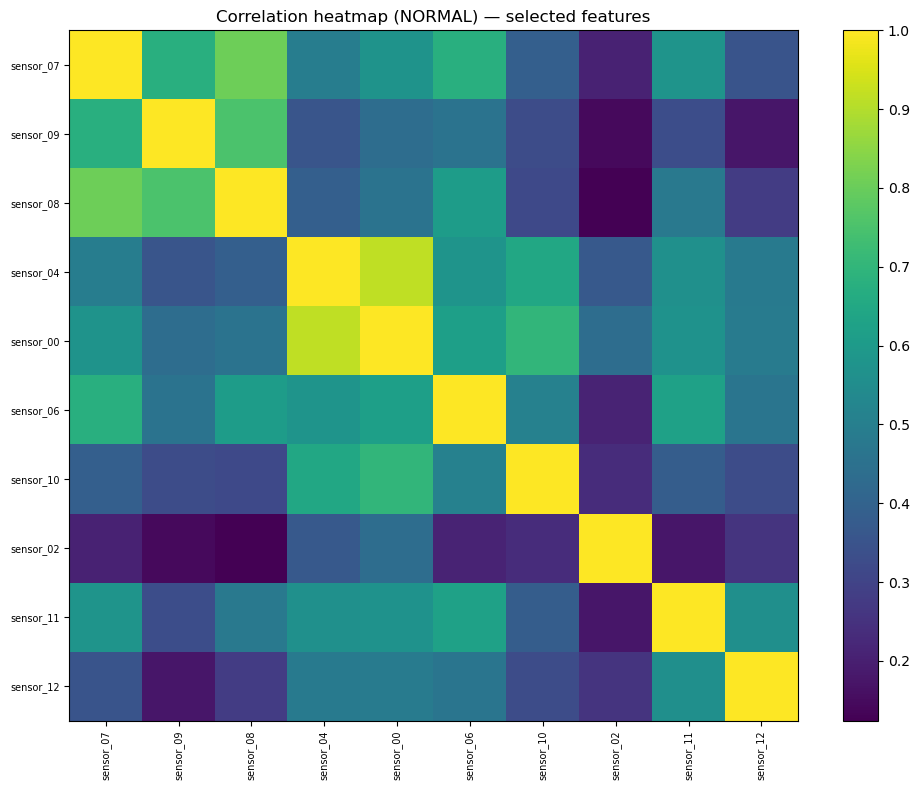

,sensor_07,sensor_09,sensor_08,sensor_04,sensor_00,sensor_06,sensor_10,sensor_02,sensor_11,sensor_12
sensor_07,1.000,0.676,0.806,0.496,0.573,0.678,0.388,0.207,0.576,0.352
sensor_09,0.676,1.000,0.752,0.354,0.439,0.457,0.329,0.148,0.333,0.179
sensor_08,0.806,0.752,1.000,0.391,0.459,0.610,0.318,0.124,0.478,0.280
sensor_04,0.496,0.354,0.391,1.000,0.915,0.577,0.650,0.368,0.565,0.484
sensor_00,0.573,0.439,0.459,0.915,1.000,0.619,0.701,0.439,0.571,0.490
sensor_06,0.678,0.457,0.610,0.577,0.619,1.000,0.509,0.211,0.627,0.466
sensor_10,0.388,0.329,0.318,0.650,0.701,0.509,1.000,0.234,0.382,0.326
sensor_02,0.207,0.148,0.124,0.368,0.439,0.211,0.234,1.000,0.177,0.256
sensor_11,0.576,0.333,0.478,0.565,0.571,0.627,0.382,0.177,1.000,0.561
sensor_12,0.352,0.179,0.280,0.484,0.490,0.466,0.326,0.256,0.561,1.000


In [ ]:
CORRELATION_FEATURES = TOP_FEATURES[:]

correlation_dataframe = normal_dataframe[CORRELATION_FEATURES].copy()
correlation_matrix = correlation_dataframe.corr(method="pearson")

corr_path = SILVER_EDA_ARTIFACTS_PATH / "correlation__normal.csv"
correlation_matrix.to_csv(corr_path)
wandb.save(str(corr_path))

# Heatmap
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix.values, aspect="auto")
plt.title("Correlation heatmap (NORMAL) — selected features")
plt.colorbar()
plt.xticks(range(len(CORRELATION_FEATURES)), CORRELATION_FEATURES, rotation=90, fontsize=7)
plt.yticks(range(len(CORRELATION_FEATURES)), CORRELATION_FEATURES, fontsize=7)
plt.tight_layout()

heatmap_path = SILVER_EDA_ARTIFACTS_PATH / "correlation__normal_heatmap.png"
plt.savefig(heatmap_path, dpi=200)
plt.show()

wandb.save(str(heatmap_path))

correlation_matrix.round(3)

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

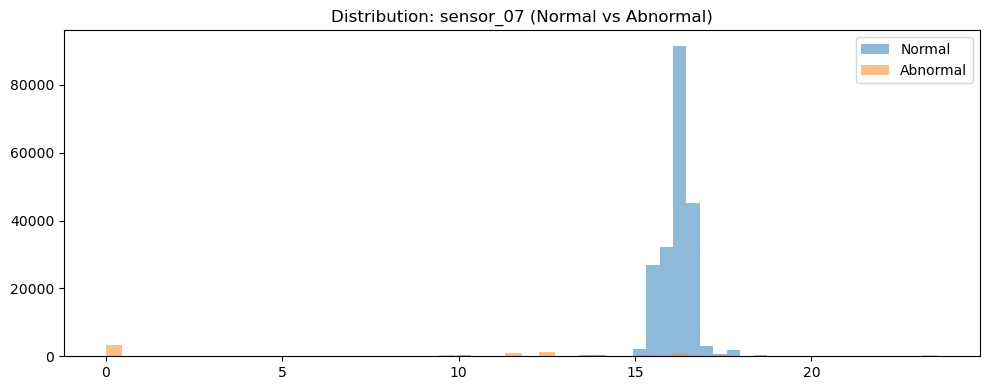

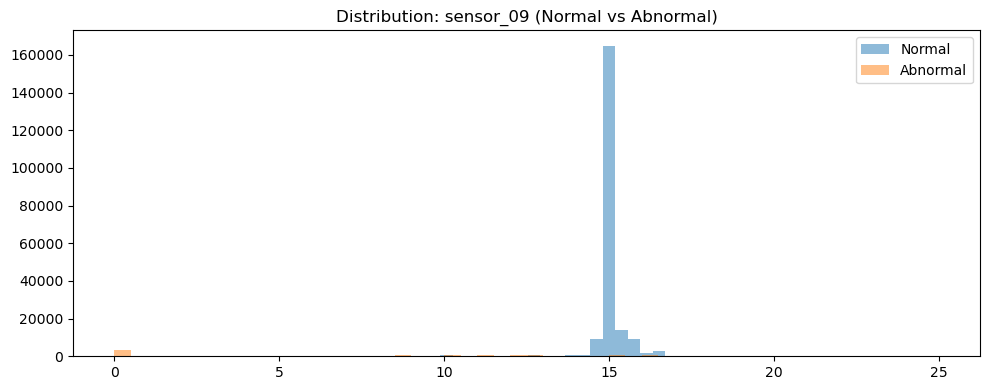

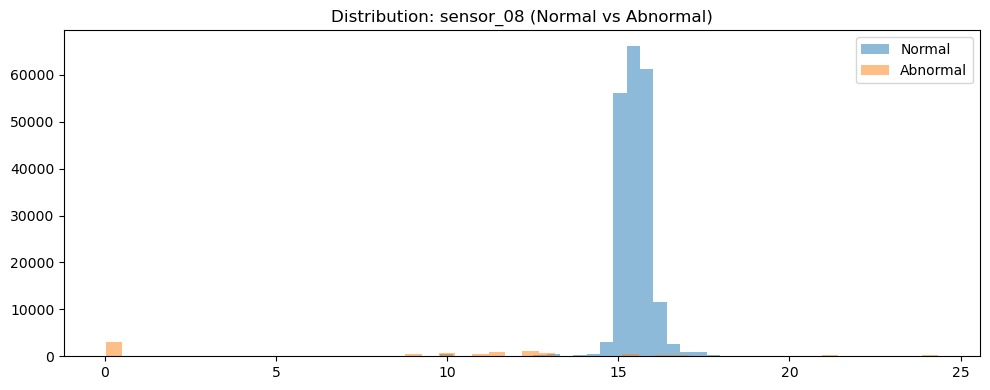

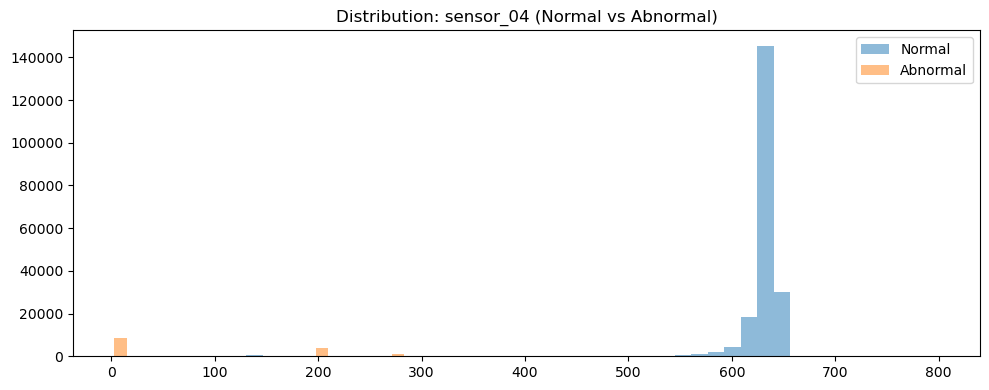

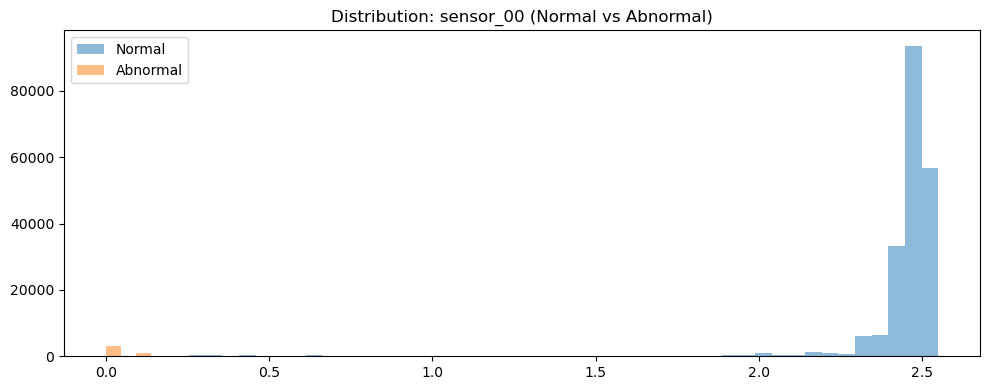

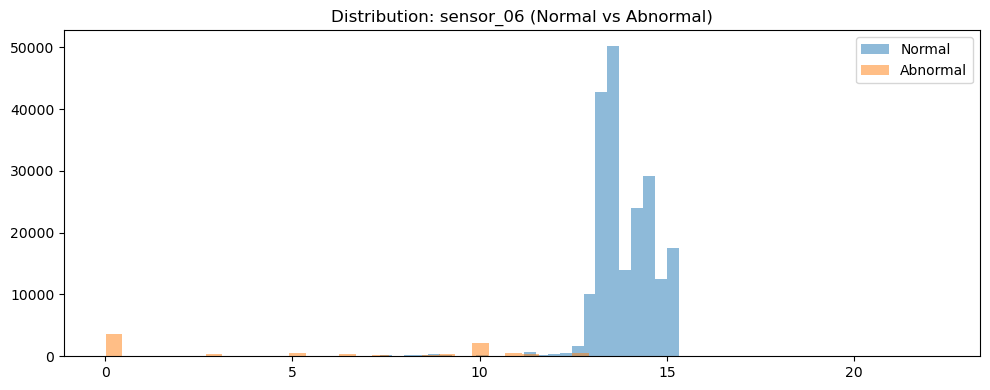

In [ ]:
plot_features = TOP_FEATURES[:] if len(TOP_FEATURES) > 0 else FEATURE_COLUMNS[:]

for feature_name in plot_features:
    if feature_name not in dataframe.columns:
        continue
    if not pd.api.types.is_numeric_dtype(dataframe[feature_name]):
        continue

    plt.figure(figsize=(10, 4))

    series_normal = normal_dataframe[feature_name].dropna()
    series_abnormal = abnormal_dataframe[feature_name].dropna()

    # Use hist with alpha via default; do not set colors explicitly
    plt.hist(series_normal.values, bins=50, alpha=0.5, label="Normal")
    plt.hist(series_abnormal.values, bins=50, alpha=0.5, label="Abnormal")

    plt.title(f"Distribution: {feature_name} (Normal vs Abnormal)")
    plt.legend()
    plt.tight_layout()

    out_path = SILVER_EDA_ARTIFACTS_PATH / f"distribution__{feature_name}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()

    wandb.save(str(out_path))

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

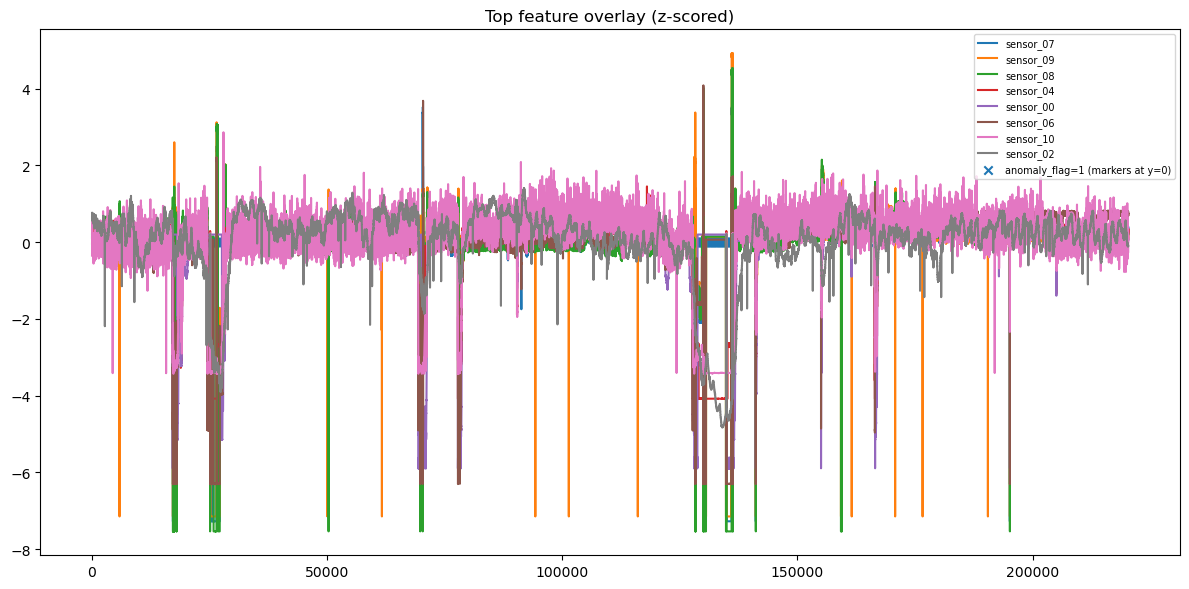

['/workspace/wandb/wandb/run-20260301_045325-484lyt2e/files/pump/timeseries__top_features_overlay.png']

In [ ]:
plot_features = TOP_FEATURES[:] if len(TOP_FEATURES) > 0 else FEATURE_COLUMNS[:]

plt.figure(figsize=(12, 6))

x_axis = dataframe["time_index"] if "time_index" in dataframe.columns else np.arange(len(dataframe))

for feature_name in plot_features:
    if feature_name not in dataframe.columns:
        continue
    if not pd.api.types.is_numeric_dtype(dataframe[feature_name]):
        continue
    series = dataframe[feature_name].copy()
    series = series.fillna(series.median())
    plt.plot(x_axis, z_score(series), label=feature_name)

# Mark anomalies if present
if "anomaly_flag" in dataframe.columns:
    anomaly_positions = dataframe.index[dataframe["anomaly_flag"] == 1].tolist()
    if len(anomaly_positions) > 0:
        # draw sparse markers to avoid heavy rendering
        marker_positions = anomaly_positions[::max(1, len(anomaly_positions)//200)]
        plt.scatter(x_axis.iloc[marker_positions] if hasattr(x_axis, "iloc") else np.array(x_axis)[marker_positions],
                    np.zeros(len(marker_positions)),
                    marker="x",
                    label="anomaly_flag=1 (markers at y=0)")

plt.title("Top feature overlay (z-scored)")
plt.legend(fontsize=7)
plt.tight_layout()

overlay_path = SILVER_EDA_ARTIFACTS_PATH / "timeseries__top_features_overlay.png"
plt.savefig(overlay_path, dpi=200)
plt.show()

wandb.save(str(overlay_path))

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

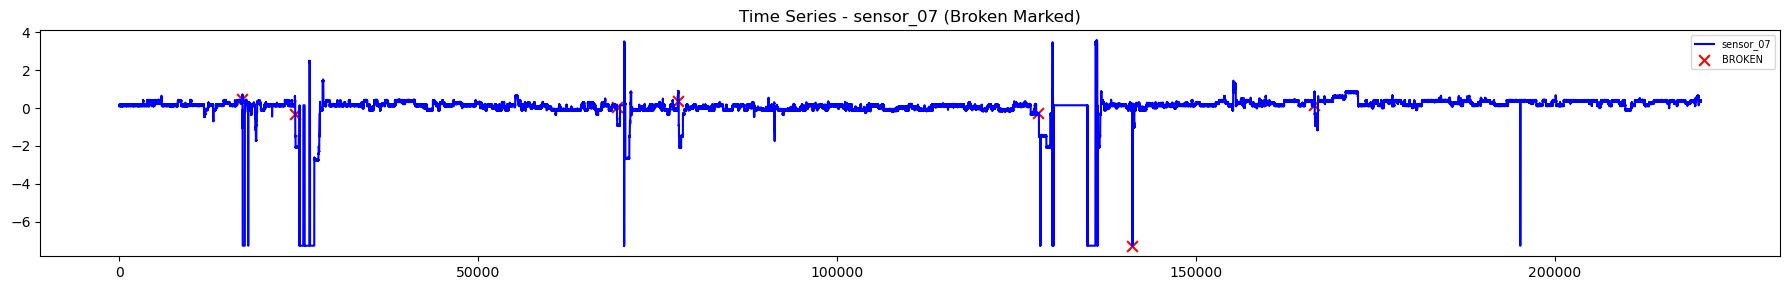

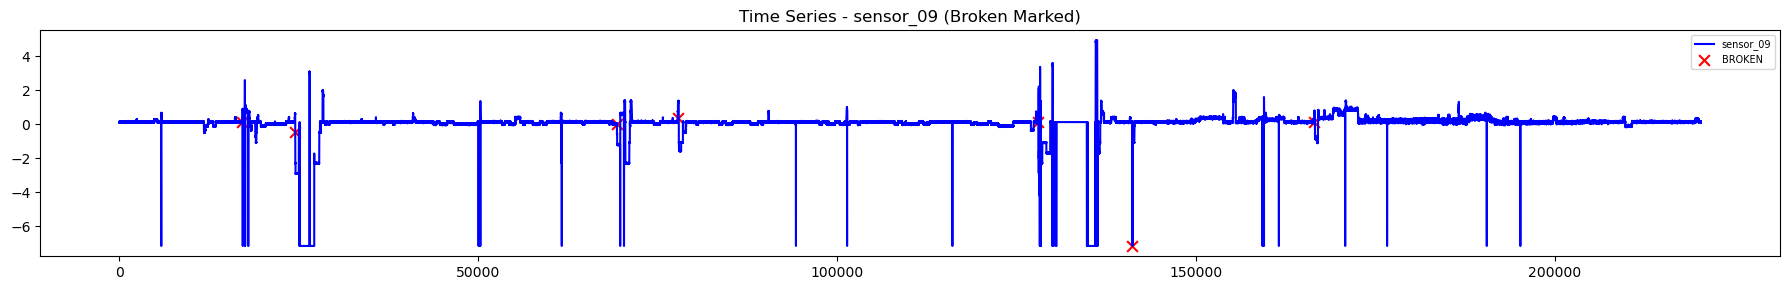

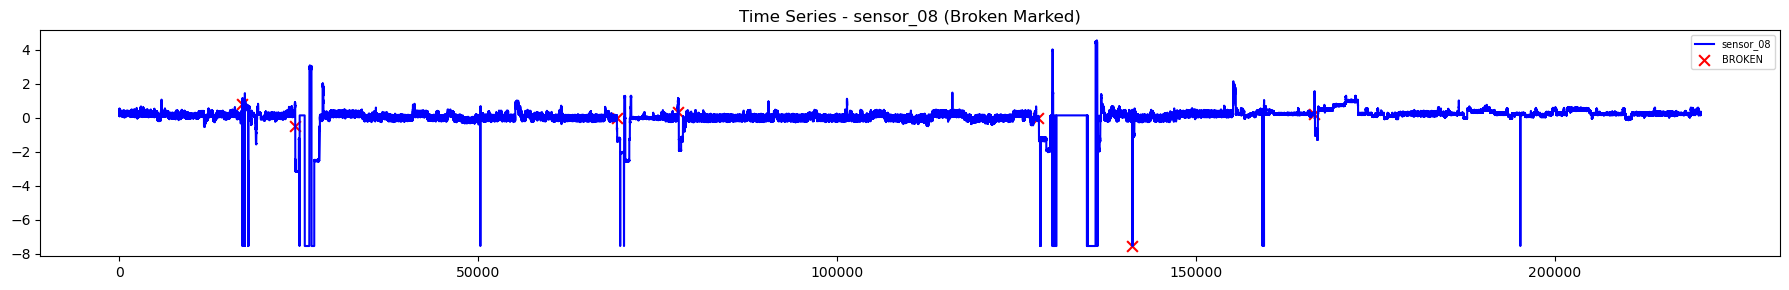

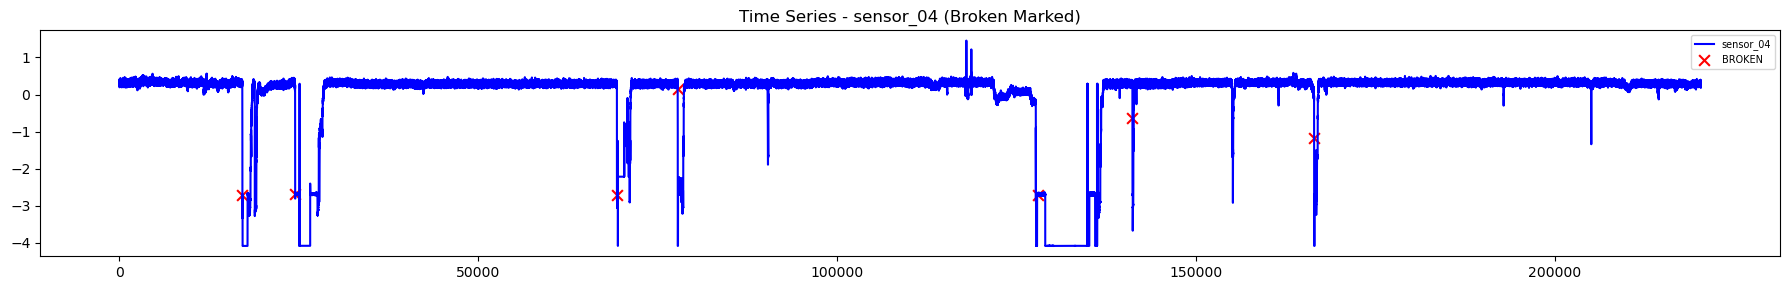

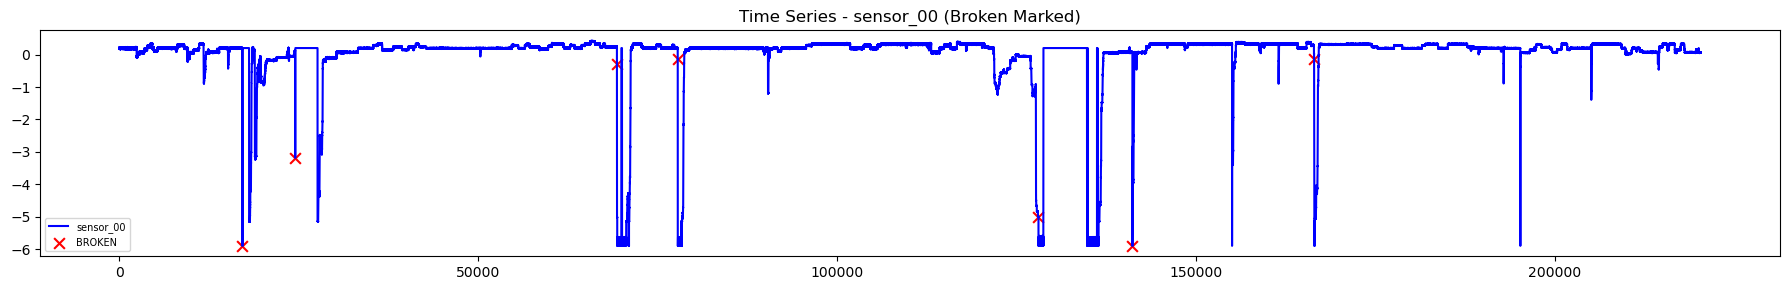

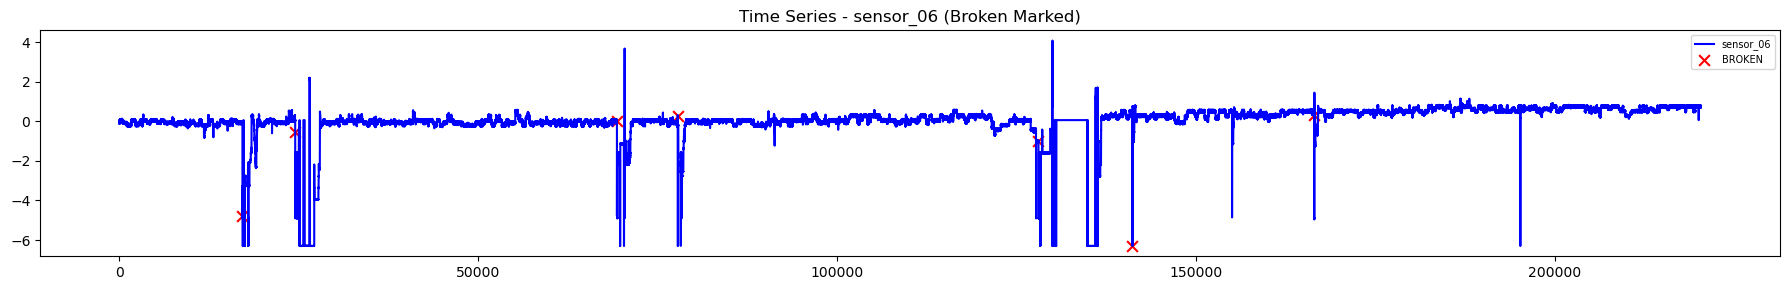

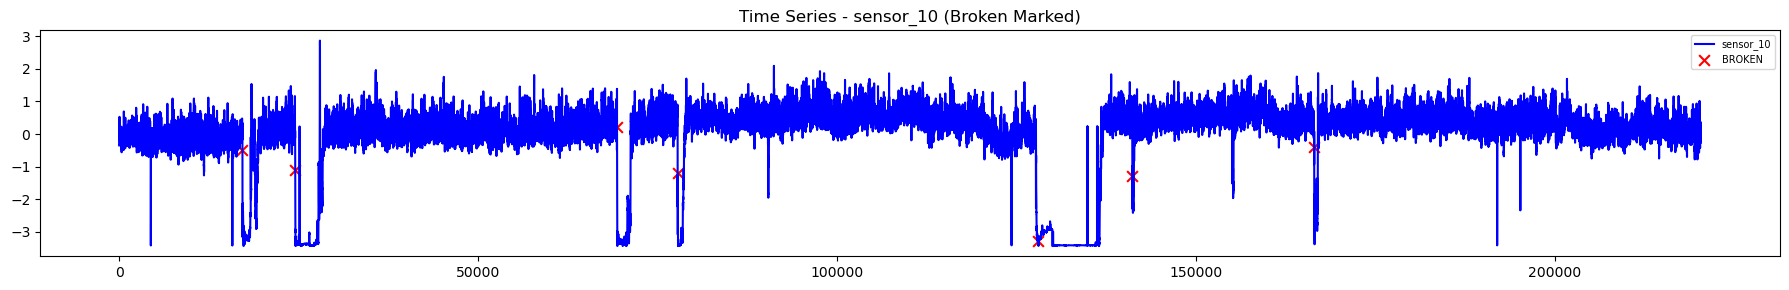

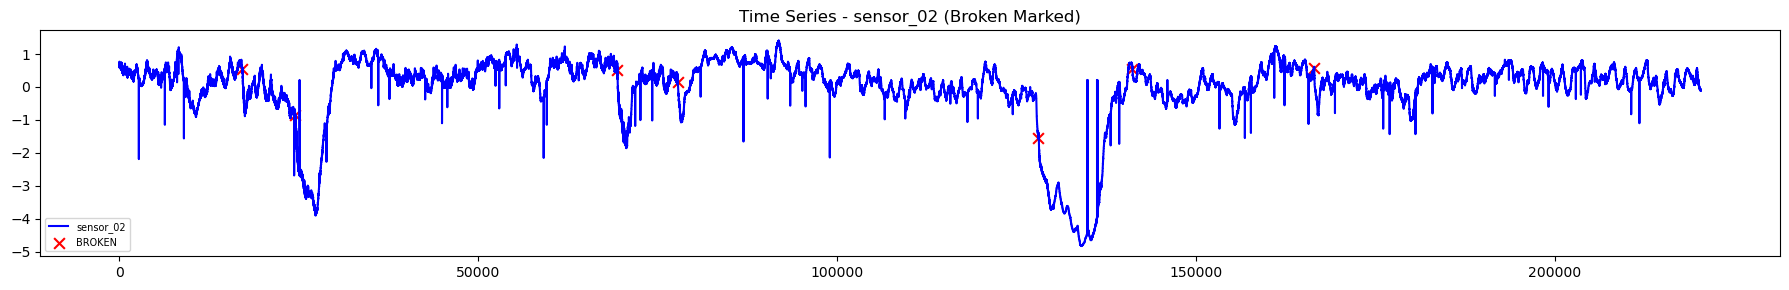

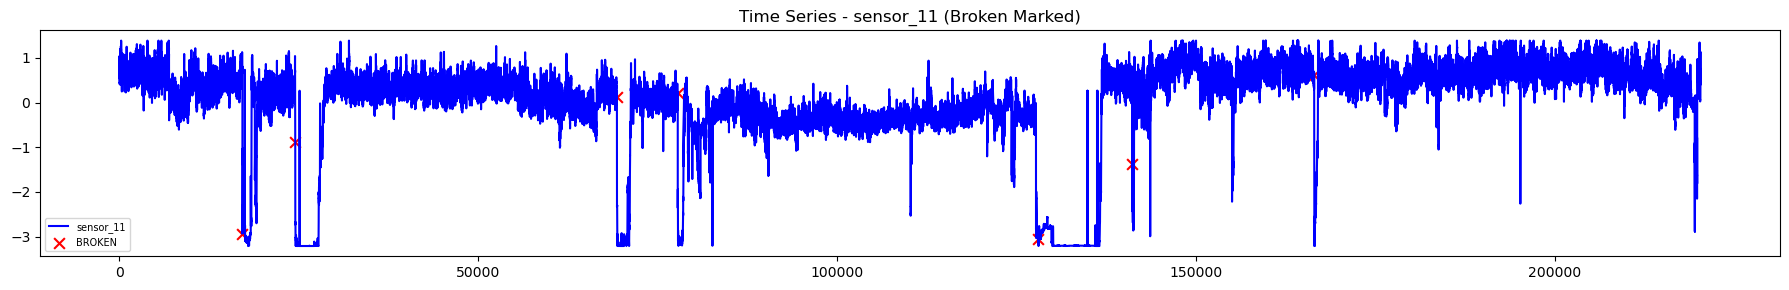

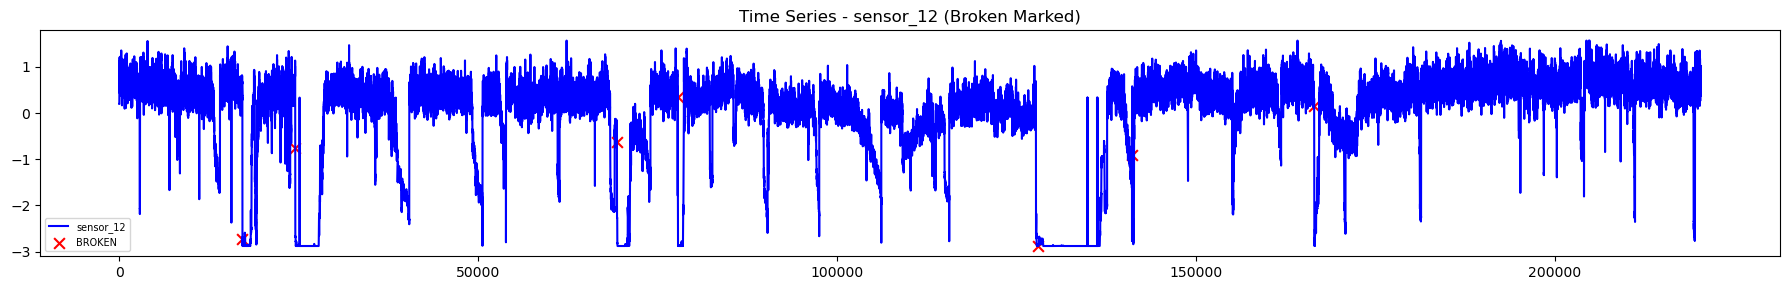

In [ ]:
plot_features = TOP_FEATURES[:] if len(TOP_FEATURES) > 0 else FEATURE_COLUMNS[:]

if "machine_status" in dataframe.columns:
    broken_mask = dataframe["machine_status"].eq("BROKEN")
elif "anomaly_flag" in dataframe.columns:
    broken_mask = dataframe["anomaly_flag"].eq(1)
else:
    broken_mask = pd.Series(False, index=dataframe.index)   

x_axis = dataframe["time_index"] if "time_index" in dataframe.columns else np.arange(len(dataframe))

broken_positions = np.flatnonzero(broken_mask.to_numpy())

for feature_name in plot_features:
    if feature_name not in dataframe.columns:
        continue
    if not pd.api.types.is_numeric_dtype(dataframe[feature_name]):
        continue

    series = dataframe[feature_name].copy()
    median_value = series.median()
    if pd.isna(median_value):
        median_value = 0
    series = series.fillna(median_value)

    # For Normalized Values, Use this:
    # For Raw Values, Comment This and Uncomment Below
    plot_series = z_score(series)

    # For Raw Values, use this:
    # For Normalize, Comment This and Uncomment Above
    # plot_series = series.to_numpy()

    plt.figure(figsize=(18, 3))
    plt.plot(x_axis, plot_series, color="blue", label=feature_name)

    if len(broken_positions) > 0:
        step = max(1, len(broken_positions) // 200)
        marker_positions = broken_positions[::step]

        x_marker_values = (
            x_axis.iloc[marker_positions]
            if hasattr(x_axis, "iloc")
            else np.asarray(x_axis)[marker_positions]
        )
        y_marker_values = np.asarray(plot_series)[marker_positions]

        plt.scatter(
            x_marker_values,
            y_marker_values,
            color="red",
            marker="x",
            s=60,
            label="BROKEN"
        )

    plt.title(f"Time Series - {feature_name} (Broken Marked)")
    plt.legend(fontsize=7)
    plt.tight_layout()

    feature_plot_path = SILVER_EDA_ARTIFACTS_PATH / f"timeseries__{feature_name}__broken_marked.png"
    plt.savefig(feature_plot_path, dpi=200)
    plt.show()
    plt.close()

    wandb.save(str(feature_plot_path))
    

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:


# Use NORMAL correlation for clustering

ALL_FEATURES = [column for column in FEATURE_COLUMNS if column in dataframe.columns and pd.api.types.is_numeric_dtype(dataframe[column])]

cluster_features = ALL_FEATURES[:]  # all numeric features
cluster_dataframe = normal_dataframe[cluster_features].copy()

# Fill missing with median so correlation works
for feature_name in cluster_features:
    cluster_dataframe[feature_name] = cluster_dataframe[feature_name].fillna(cluster_dataframe[feature_name].median())

correlation_matrix = cluster_dataframe.corr(method="pearson").fillna(0.0)

# Convert correlation to distance (0 = identical, 1 = unrelated)
distance_matrix = 1.0 - correlation_matrix.abs()

# Choose a small number of clusters to start (you can tune)
cluster_count = 6 if len(cluster_features) >= 6 else max(2, len(cluster_features))

model = AgglomerativeClustering(
    n_clusters=cluster_count,
    metric="precomputed",
    linkage="average",
)

labels = model.fit_predict(distance_matrix.values)

cluster_rows = []
for feature_name, cluster_label in zip(cluster_features, labels):
    cluster_rows.append({
        "feature": feature_name,
        "cluster_id": int(cluster_label),
    })

cluster_table = pd.DataFrame(cluster_rows).sort_values(["cluster_id", "feature"])

cluster_path = SILVER_EDA_ARTIFACTS_PATH / "clusters__correlation_agglomerative.csv"
cluster_table.to_csv(cluster_path, index=False)
wandb.save(str(cluster_path))

cluster_table.head(30)

,feature,cluster_id
0,sensor_00,0
4,sensor_04,0
5,sensor_05,0
6,sensor_06,0
7,sensor_07,0
8,sensor_08,0
9,sensor_09,0
10,sensor_10,0
11,sensor_11,0
12,sensor_12,0


In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

2026-03-01 04:54:05,072 | INFO | capstone.silver_eda | Anomaly onsets found: 7


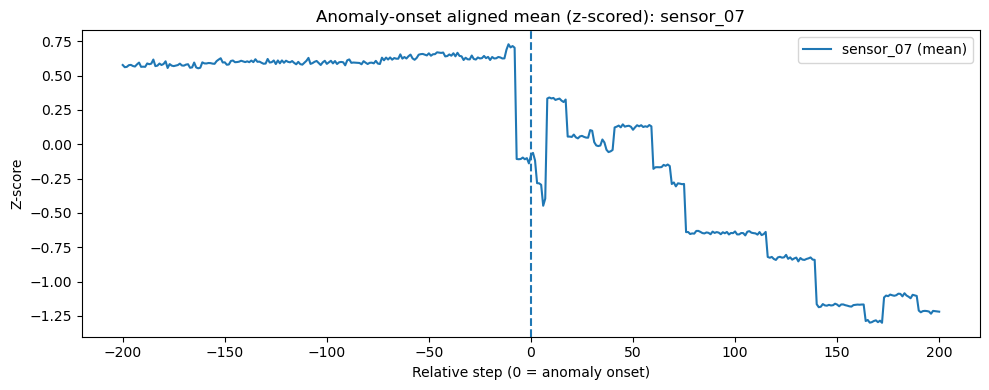

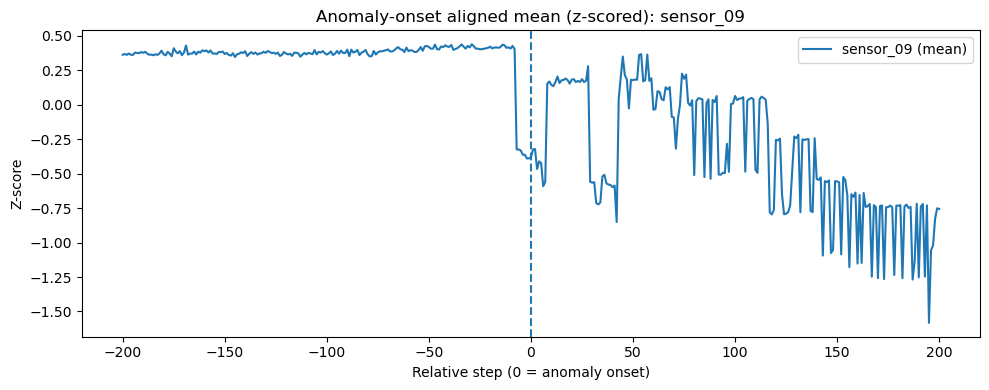

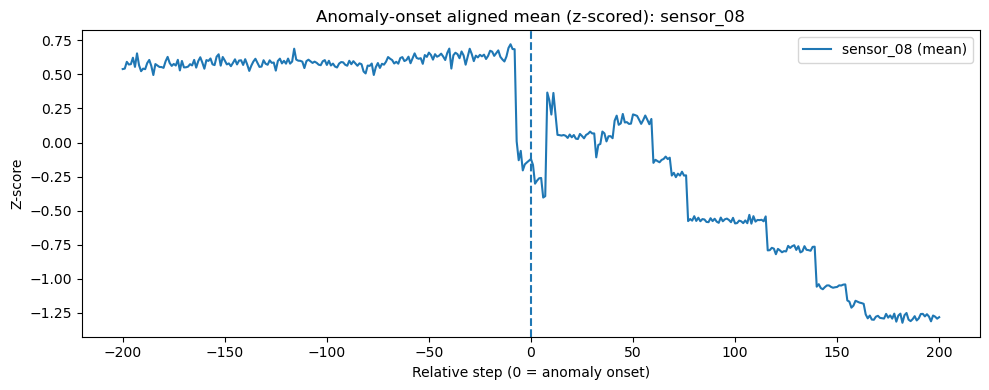

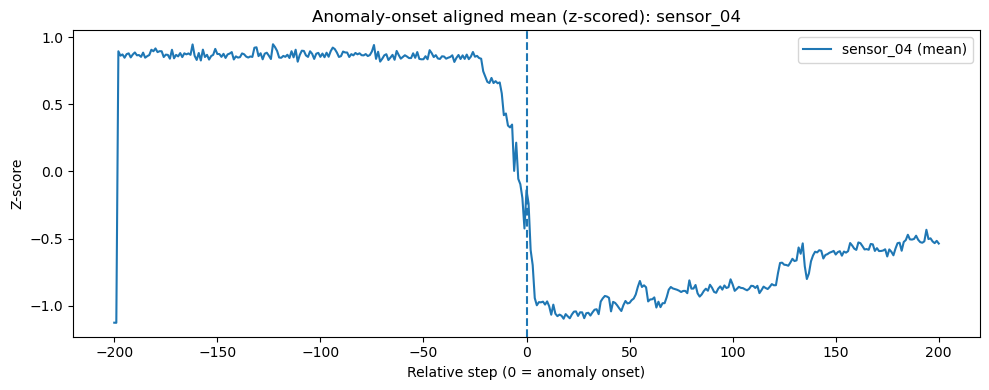

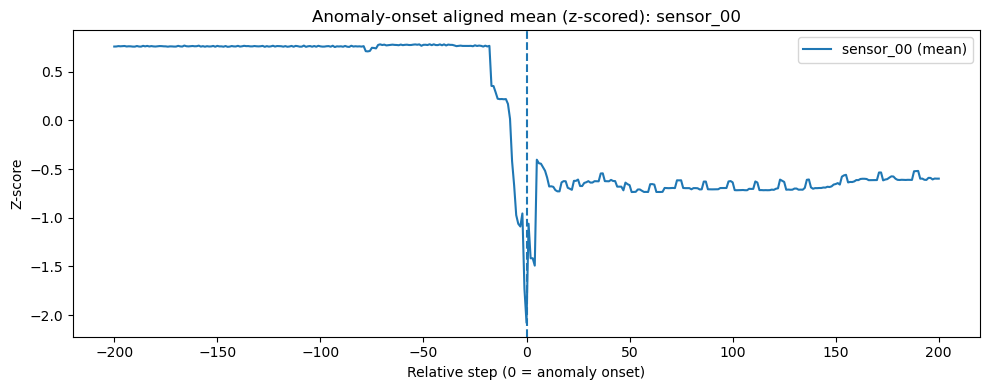

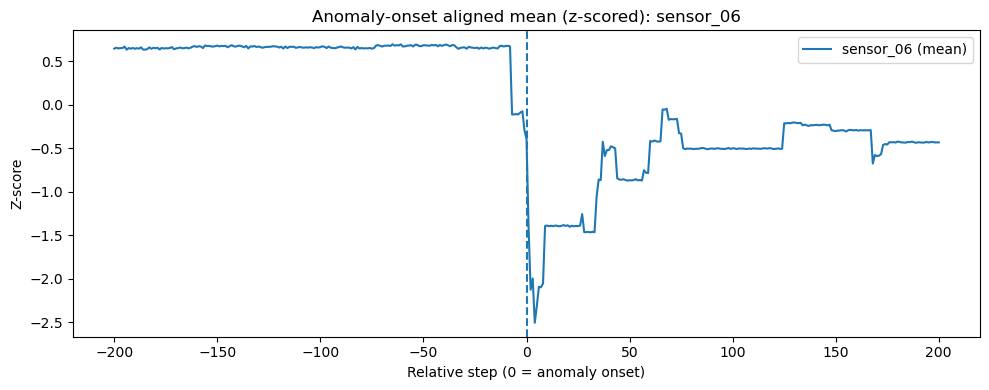

(['sensor_07',
  'sensor_09',
  'sensor_08',
  'sensor_04',
  'sensor_00',
  'sensor_06'],
 7)

In [ ]:
def find_anomaly_onsets(dataframe: pd.DataFrame) -> pd.DataFrame:
    if "anomaly_flag" not in dataframe.columns:
        return pd.DataFrame(columns=["meta__asset_id", "meta__run_id", "time_index", "event_step"])

    grouping_columns = []
    if "meta__asset_id" in dataframe.columns:
        grouping_columns.append("meta__asset_id")
    if "meta__run_id" in dataframe.columns:
        grouping_columns.append("meta__run_id")

    working = dataframe.copy()

    if "event_step" not in working.columns and "time_index" in working.columns:
        working["event_step"] = working["time_index"]

    if "time_index" not in working.columns:
        working["time_index"] = np.arange(len(working), dtype=np.int64)

    # Ensure sorted within group for consistent onset detection
    if len(grouping_columns) > 0:
        working = working.sort_values(grouping_columns + ["event_step"]).reset_index(drop=True)
        shifted = working.groupby(grouping_columns, dropna=False)["anomaly_flag"].shift(1)
    else:
        working = working.sort_values(["event_step"]).reset_index(drop=True)
        shifted = working["anomaly_flag"].shift(1)

    onset_mask = (working["anomaly_flag"] == 1) & (shifted.fillna(0) == 0)
    onsets = working.loc[onset_mask, grouping_columns + ["time_index", "event_step"]].copy()
    return onsets.reset_index(drop=True)

def sample_onsets_evenly(onsets: pd.DataFrame, max_count: int) -> pd.DataFrame:
    if len(onsets) <= max_count:
        return onsets
    indices = np.linspace(0, len(onsets) - 1, num=max_count)
    indices = [int(round(value)) for value in indices]
    indices = sorted(list(set(indices)))
    return onsets.iloc[indices].reset_index(drop=True)

onsets_table = find_anomaly_onsets(dataframe)
onsets_table = sample_onsets_evenly(onsets_table, MAX_ONSETS_TO_USE)

onsets_path = SILVER_EDA_ARTIFACTS_PATH / "anomaly_onsets__table.csv"
onsets_table.to_csv(onsets_path, index=False)
wandb.save(str(onsets_path))

logger.info("Anomaly onsets found: %d", len(onsets_table))

# Choose features to align (use TOP_FEATURES if you already computed them; otherwise fallback)
aligned_features = []
for feature_name in TOP_FEATURES if "TOP_FEATURES" in globals() else FEATURE_COLUMNS:
    if feature_name in dataframe.columns and pd.api.types.is_numeric_dtype(dataframe[feature_name]):
        aligned_features.append(feature_name)
    if len(aligned_features) >= 6:
        break

if len(aligned_features) == 0 or len(onsets_table) == 0:
    logger.info("Skipping anomaly-onset alignment (no onsets or no numeric aligned features).")
else:
    relative_steps = np.arange(-PRE_WINDOW_STEPS, POST_WINDOW_STEPS + 1, dtype=np.int64)

    # Build aligned matrices: one matrix per feature, rows = onsets, cols = relative steps
    aligned_mean_rows = []

    for feature_name in aligned_features:
        aligned_values = []

        for onset_index in range(len(onsets_table)):
            onset_row = onsets_table.iloc[onset_index]

            # Filter to the onset's group if asset/run exist
            subset = dataframe
            if "meta__asset_id" in onsets_table.columns:
                subset = subset[subset["meta__asset_id"] == onset_row["meta__asset_id"]]
            if "meta__run_id" in onsets_table.columns:
                subset = subset[subset["meta__run_id"] == onset_row["meta__run_id"]]

            # Ensure ordering by event_step
            if "event_step" in subset.columns:
                subset = subset.sort_values("event_step")
            else:
                subset = subset.sort_values("time_index")

            onset_step = int(onset_row["event_step"])
            start_step = onset_step - PRE_WINDOW_STEPS
            end_step = onset_step + POST_WINDOW_STEPS

            window = subset[(subset["event_step"] >= start_step) & (subset["event_step"] <= end_step)].copy()
            if len(window) == 0:
                continue

            # Reindex to complete relative step range (so we can average across onsets)
            window["relative_step"] = window["event_step"].astype(int) - onset_step
            window = window.set_index("relative_step")

            # Build full aligned vector with NaNs where missing
            aligned_vector = pd.Series(index=relative_steps, dtype=float)
            feature_series = window[feature_name].astype(float)

            # Fill aligned_vector values
            for step_value in feature_series.index:
                if int(step_value) in aligned_vector.index:
                    aligned_vector.loc[int(step_value)] = float(feature_series.loc[step_value])

            # Normalize within-window (z-score) after filling with median to avoid NaN explosion
            filled = aligned_vector.copy()
            median_value = float(np.nanmedian(filled.values))
            filled = filled.fillna(median_value)
            normalized = z_score(filled)

            aligned_values.append(normalized.values)

        if len(aligned_values) == 0:
            continue

        aligned_matrix = np.vstack(aligned_values)
        mean_curve = aligned_matrix.mean(axis=0)

        aligned_mean_rows.append({
            "feature": feature_name,
            "onsets_used": int(aligned_matrix.shape[0]),
        })

        # Plot mean curve
        plt.figure(figsize=(10, 4))
        plt.plot(relative_steps, mean_curve, label=f"{feature_name} (mean)")
        plt.axvline(0, linestyle="--")  # onset marker
        plt.title(f"Anomaly-onset aligned mean (z-scored): {feature_name}")
        plt.xlabel("Relative step (0 = anomaly onset)")
        plt.ylabel("Z-score")
        plt.legend()
        plt.tight_layout()

        plot_path = SILVER_EDA_ARTIFACTS_PATH / f"aligned_onset__mean__{feature_name}.png"
        plt.savefig(plot_path, dpi=200)
        plt.show()
        wandb.save(str(plot_path))

    aligned_summary = pd.DataFrame(aligned_mean_rows)
    aligned_summary_path = SILVER_EDA_ARTIFACTS_PATH / "aligned_onset__summary.csv"
    aligned_summary.to_csv(aligned_summary_path, index=False)
    wandb.save(str(aligned_summary_path))

aligned_features, len(onsets_table)

In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

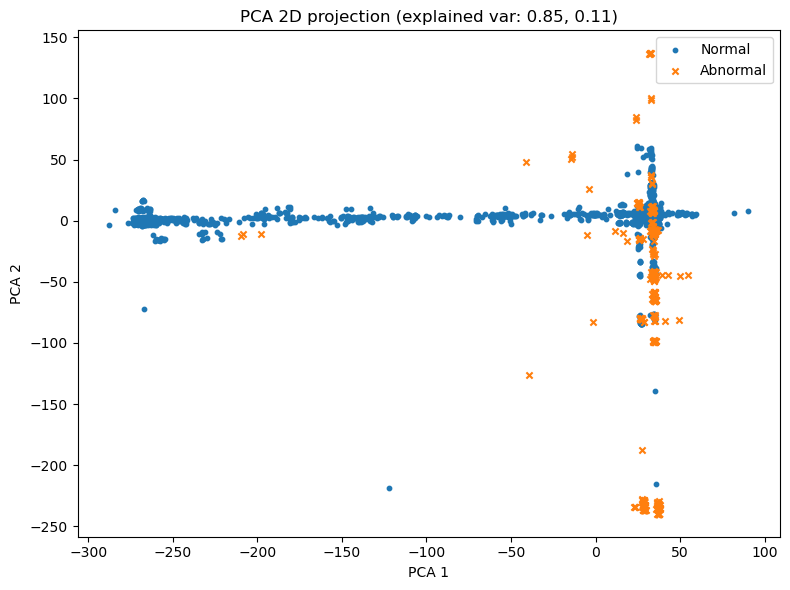

2026-03-01 04:54:24,182 | INFO | capstone.silver_eda | LEDGER | {'ts_utc': '2026-03-01T04:54:24.182449+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'pca_2d_projection', 'message': 'Computed PCA(2) projection for separation check.', 'why': None, 'consequence': None, 'data': {'numeric_feature_count': 50, 'rows_used': 8000, 'scaler': 'RobustScaler', 'explained_variance_ratio': [0.8520313514930179, 0.11306601074922507], 'pca_table_path': '/workspace/artifacts/silver_eda/pump/pca_2d__table.csv', 'pca_plot_path': '/workspace/artifacts/silver_eda/pump/pca_2d__scatter.png'}}


In [ ]:


# Collect numeric feature columns that exist
numeric_feature_columns = []
for feature_name in FEATURE_COLUMNS:
    if feature_name in dataframe.columns and pd.api.types.is_numeric_dtype(dataframe[feature_name]):
        numeric_feature_columns.append(feature_name)

if len(numeric_feature_columns) == 0:
    logger.info("No numeric feature columns available for PCA.")
else:
    modeling_frame = dataframe[numeric_feature_columns + (["anomaly_flag"] if "anomaly_flag" in dataframe.columns else [])].copy()

    # Optional sampling (keeps PCA fast)
    if len(modeling_frame) > PCA_SAMPLE_ROW_COUNT:
        modeling_frame = modeling_frame.sample(n=PCA_SAMPLE_ROW_COUNT, random_state=42).reset_index(drop=True)

    feature_matrix = modeling_frame[numeric_feature_columns].copy()

    # Median imputation (simple, stable)
    for feature_name in numeric_feature_columns:
        median_value = float(feature_matrix[feature_name].median(skipna=True))
        feature_matrix[feature_name] = feature_matrix[feature_name].fillna(median_value)

    # Scaling
    scaler = RobustScaler() if USE_ROBUST_SCALER else StandardScaler()
    scaled_matrix = scaler.fit_transform(feature_matrix.values)

    # PCA
    pca_model = PCA(n_components=2, random_state=42)
    pca_values = pca_model.fit_transform(scaled_matrix)

    pca_dataframe = pd.DataFrame({
        "pca_1": pca_values[:, 0],
        "pca_2": pca_values[:, 1],
    })

    if "anomaly_flag" in modeling_frame.columns:
        pca_dataframe["anomaly_flag"] = modeling_frame["anomaly_flag"].astype(int).values
    else:
        pca_dataframe["anomaly_flag"] = 0

    # Save PCA table
    pca_table_path = SILVER_EDA_ARTIFACTS_PATH / "pca_2d__table.csv"
    pca_dataframe.to_csv(pca_table_path, index=False)
    wandb.save(str(pca_table_path))

    # Plot normal and abnormal as separate scatters (matplotlib assigns colors automatically)
    plt.figure(figsize=(8, 6))
    normal_points = pca_dataframe[pca_dataframe["anomaly_flag"] == 0]
    abnormal_points = pca_dataframe[pca_dataframe["anomaly_flag"] == 1]

    plt.scatter(normal_points["pca_1"], normal_points["pca_2"], s=10, label="Normal")
    if len(abnormal_points) > 0:
        plt.scatter(abnormal_points["pca_1"], abnormal_points["pca_2"], s=20, marker="x", label="Abnormal")

    explained = pca_model.explained_variance_ratio_
    plt.title(f"PCA 2D projection (explained var: {explained[0]:.2f}, {explained[1]:.2f})")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.tight_layout()

    pca_plot_path = SILVER_EDA_ARTIFACTS_PATH / "pca_2d__scatter.png"
    plt.savefig(pca_plot_path, dpi=200)
    plt.show()
    wandb.save(str(pca_plot_path))

    ledger.add(
        kind="step",
        step="pca_2d_projection",
        message="Computed PCA(2) projection for separation check.",
        data={
            "numeric_feature_count": int(len(numeric_feature_columns)),
            "rows_used": int(len(pca_dataframe)),
            "scaler": "RobustScaler" if USE_ROBUST_SCALER else "StandardScaler",
            "explained_variance_ratio": [float(explained[0]), float(explained[1])],
            "pca_table_path": str(pca_table_path),
            "pca_plot_path": str(pca_plot_path),
        },
        logger=logger,
    )



In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:

# Pick numeric features only
numeric_feature_columns = []
for feature_name in FEATURE_COLUMNS:
    if feature_name in dataframe.columns and pd.api.types.is_numeric_dtype(dataframe[feature_name]):
        numeric_feature_columns.append(feature_name)

if len(numeric_feature_columns) == 0:
    logger.info("No numeric feature columns available for imputation comparison.")
else:
    working = dataframe[numeric_feature_columns + (["meta__asset_id", "meta__run_id", "event_step"] if "event_step" in dataframe.columns else [])].copy()

    if len(working) > IMPUTE_SAMPLE_ROW_COUNT:
        working = working.sample(n=IMPUTE_SAMPLE_ROW_COUNT, random_state=42).reset_index(drop=True)

    # Strategy A: median imputation (global)
    median_imputed = working[numeric_feature_columns].copy()
    for feature_name in numeric_feature_columns:
        median_value = float(median_imputed[feature_name].median(skipna=True))
        median_imputed[feature_name] = median_imputed[feature_name].fillna(median_value)

    # Strategy B: mean imputation (global)
    mean_imputed = working[numeric_feature_columns].copy()
    for feature_name in numeric_feature_columns:
        mean_value = float(mean_imputed[feature_name].mean(skipna=True))
        mean_imputed[feature_name] = mean_imputed[feature_name].fillna(mean_value)

    # Strategy C: forward fill within (asset, run) if available, then median
    ffill_imputed = working.copy()
    grouping_columns = []
    if "meta__asset_id" in ffill_imputed.columns:
        grouping_columns.append("meta__asset_id")
    if "meta__run_id" in ffill_imputed.columns:
        grouping_columns.append("meta__run_id")

    if len(grouping_columns) > 0 and "event_step" in ffill_imputed.columns:
        ffill_imputed = ffill_imputed.sort_values(grouping_columns + ["event_step"]).reset_index(drop=True)
        for feature_name in numeric_feature_columns:
            ffill_imputed[feature_name] = ffill_imputed.groupby(grouping_columns, dropna=False)[feature_name].ffill()
    # finish with median for any remaining missing
    for feature_name in numeric_feature_columns:
        median_value = float(ffill_imputed[feature_name].median(skipna=True))
        ffill_imputed[feature_name] = ffill_imputed[feature_name].fillna(median_value)

    # Compare strategies on: percent filled and mean absolute change on originally-missing positions
    comparison_rows = []
    for feature_name in numeric_feature_columns:
        original_series = working[feature_name]
        missing_mask = original_series.isna()

        missing_count = int(missing_mask.sum())
        if missing_count == 0:
            continue

        # Values that got filled at missing positions
        filled_median = median_imputed.loc[missing_mask, feature_name].astype(float)
        filled_mean = mean_imputed.loc[missing_mask, feature_name].astype(float)
        filled_ffill = ffill_imputed.loc[missing_mask, feature_name].astype(float)

        # Compare filled values to the non-missing distribution center (median)
        non_missing = original_series.dropna().astype(float)
        baseline_median = float(non_missing.median()) if len(non_missing) > 0 else 0.0

        median_abs_shift = float((filled_median - baseline_median).abs().mean())
        mean_abs_shift = float((filled_mean - baseline_median).abs().mean())
        ffill_abs_shift = float((filled_ffill - baseline_median).abs().mean())

        comparison_rows.append({
            "feature": feature_name,
            "missing_count": missing_count,
            "missing_percent": float((missing_count / len(working)) * 100.0),
            "baseline_median": baseline_median,
            "median_impute_mean_abs_shift_from_median": median_abs_shift,
            "mean_impute_mean_abs_shift_from_median": mean_abs_shift,
            "ffill_then_median_mean_abs_shift_from_median": ffill_abs_shift,
        })

    impute_compare_table = pd.DataFrame(comparison_rows).sort_values("missing_percent", ascending=False)

    impute_compare_path = SILVER_EDA_ARTIFACTS_PATH / "imputation__comparison.csv"
    impute_compare_table.to_csv(impute_compare_path, index=False)
    wandb.save(str(impute_compare_path))

    # Recommendation logic (simple, explainable)
    # If time-ordered groups exist, ffill+median is often best for time series continuity.
    # Otherwise, median is the safest global method.
    has_groups = ("meta__asset_id" in dataframe.columns) and ("meta__run_id" in dataframe.columns)
    has_event_step = "event_step" in dataframe.columns

    if has_groups and has_event_step:
        recommendation = "forward_fill_within_group_then_median"
        recommendation_reason = (
            "Dataset has (asset,run) grouping and event_step ordering; forward fill preserves short gaps "
            "in time series while median handles leading gaps and long missing runs."
        )
    else:
        recommendation = "global_median"
        recommendation_reason = (
            "Dataset does not clearly support within-group forward fill; global median is robust to outliers "
            "and stable for Isolation Forest and One-Class SVM."
        )

    recommendation_payload = {
        "recommendation": recommendation,
        "reason": recommendation_reason,
        "has_grouping_columns": bool(has_groups),
        "has_event_step": bool(has_event_step),
        "comparison_csv": str(impute_compare_path),
    }

    save_json(recommendation_payload, file_path=SILVER_EDA_ARTIFACTS_PATH, file_name="imputation__recommendation.json")
    wandb.save(str(SILVER_EDA_ARTIFACTS_PATH / "imputation__recommendation.json"))

    ledger.add(
        kind="decision",
        step="imputation_recommendation",
        message="Compared basic imputation strategies and recorded recommendation for Gold layer.",
        data=recommendation_payload,
        logger=logger,
    )

    impute_compare_table.head(15), recommendation_payload

2026-03-01 04:54:24,777 | INFO | capstone.file_io | Saved JSON: /workspace/artifacts/silver_eda/pump/imputation__recommendation.json
2026-03-01 04:54:24,801 | INFO | capstone.silver_eda | LEDGER | {'ts_utc': '2026-03-01T04:54:24.801486+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'decision', 'step': 'imputation_recommendation', 'message': 'Compared basic imputation strategies and recorded recommendation for Gold layer.', 'why': None, 'consequence': None, 'data': {'recommendation': 'forward_fill_within_group_then_median', 'reason': 'Dataset has (asset,run) grouping and event_step ordering; forward fill preserves short gaps in time series while median handles leading gaps and long missing runs.', 'has_grouping_columns': True, 'has_event_step': True, 'comparison_csv': '/workspace/artifacts/silver_eda/pump/imputation__comparison.csv'}}


In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [ ]:
ledger_path = SILVER_EDA_ARTIFACTS_PATH / f"ledger__{DATASET_NAME}__{STAGE}.json"

ledger.add(
    kind="step",
    step="finalize",
    message="Saved Silver EDA ledger and finalized W&B run.",
    data={"ledger_path": str(ledger_path)},
    logger=logger,
)

ledger.write_json(ledger_path)
wandb.save(str(ledger_path))
wandb_run.finish()

2026-03-01 04:54:24,832 | INFO | capstone.silver_eda | LEDGER | {'ts_utc': '2026-03-01T04:54:24.832275+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'finalize', 'message': 'Saved Silver EDA ledger and finalized W&B run.', 'why': None, 'consequence': None, 'data': {'ledger_path': '/workspace/artifacts/silver_eda/pump/ledger__pump__silver_eda.json'}}


feature_registry_keys,▁
silver_cols,▁
silver_rows,▁
feature_registry_keys,13
silver_cols,85
silver_rows,220320


In [ ]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 